## Welcome to the Perceptron!

In this section, we will explore the **perceptron**—the foundational building block of all artificial neural networks. The code below sets up the machinery needed to build, train, and visualize a simple artificial neuron using Keras (a popular deep learning library).

Here is a quick breakdown of what this code does:

1. **Builds the Brain:** The `buildModel()` function creates a true perceptron: a single mathematical node (a `Dense` layer) combined with a `hard_sigmoid` activation. This mimics the classic "all-or-nothing" step function used in the very first neural networks.

2. **Creates Visualization Tools:** It defines two helper functions (`plotHistory` and `plotDecision`) so you can visually track *how fast* the model is learning over time and *where* it draws its decision boundary to separate data points.

3. **Prepares Historical Benchmarks:** It constructs several small datasets representing fundamental Boolean logic gates (NOT, AND, OR, XOR). These simple rules are the historical benchmark tests used to prove whether a machine learning model actually works.

4. **Executes the First Training Run:** Finally, it initializes a 1D and a 2D perceptron and begins training the 1D model to learn the basic "NOT" logic gate, using an optimizer (Adam) to adjust its weights until it finds the correct answer.

Run this cell to initialize our environment, and let's start teaching a machine to learn!

In [20]:
# Run this code if your virtual environment does not have the required libraries installed. 
# You only need to run this once per environment.
!pip install keras tensorflow matplotlib numpy pydot graphviz

     ---------------------------------------- 0.0/47.3 kB ? eta -:--:--
     ---------------------------------------- 47.3/47.3 kB 2.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.optimizers import Adam
from keras.utils import plot_model
import matplotlib.pyplot as plt
import numpy as np

###############################################################################
# Function Definitions
###############################################################################

##################################
# 1. Build Perceptrons
##################################
def buildModel(dim):
    model = Sequential()
    model.add(Dense(1, input_dim=dim))
    model.add(Activation('hard_sigmoid'))
    return model
    
   
##################################
# 3. History Plotting
##################################
def plotHistory(history, name):
    
    # # History Data
    # print(history.history.keys())
    # print(history.history['accuracy'])
    # print(history.history['val_accuracy'])
    # print(history.history['loss'])
    # print(history.history['val_loss'])
    
    # Accuracy Plot
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.ylabel('Accuracy')
    plt.xlabel('Epochs')
    plt.title('Accuracy for %s' %(name))
    plt.legend(['Training', 'Validation'])
    plt.show()
    
    # Loss Plot
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.ylabel('Loss')
    plt.xlabel('Epochs')
    plt.title('Loss for %s' %(name))
    plt.legend(['Training', 'Validation'])
    plt.show()


def plotDecision(xMatrix, yMatrix, weights, model):
    # Plotting points
    x = np.array(xMatrix[:,0].T)
    x = x.flatten()
    
    y = np.array(xMatrix[:,1].T)
    y = y.flatten()
    
    colors = np.array(yMatrix.T)
    colors = colors.flatten()
    
    
    plt.scatter(x, y, c=colors, cmap=plt.cm.Paired)
    plt.colorbar()
    
    # Plotting decision regions
    x_min, x_max = x.min() - 0.1, x.max() + 0.1
    y_min, y_max = y.min() - 0.1, y.max() + 0.1
    
#    print(x_min,x_max,y_min,y_max)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict_on_batch(np.c_[xx.ravel(), yy.ravel()]) 

    Z = Z.reshape(xx.shape)   
    plt.contour(xx, yy, Z, 1, cmap=plt.cm.Paired)
    
    plt.ylim([x_min,x_max])
#    plt.xlim([y_min,y_max])
    plt.show()



###############################################################################
# Main Body of Code
###############################################################################
np.random.seed(1)
##################################
# 1. Build Perceptrons
##################################
p1model = buildModel(1)
p2model = buildModel(2)

adam = Adam(learning_rate=0.05, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0)
p1model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
plot_model(p1model, show_shapes=True, show_layer_names=True)

p2model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
plot_model(p1model, show_shapes=True, show_layer_names=True)


##################################
# 2. Build Boolean Matrices
##################################
xOne = np.asmatrix('1; 0')
xTwo = np.asmatrix('1,1; 1,0; 0,1; 0,0')
yNot = np.asmatrix('0;1')
yOr = np.asmatrix('1;1;1;0')
yAnd = np.asmatrix('1;0;0;0')
yXOR = np.asmatrix('0;1;1;0')


#Validation matrices
xOneVal = np.asmatrix('1')
xTwoVal = np.asmatrix('1,1; 1,0')
yNotVal = np.asmatrix('0')
yOrVal = np.asmatrix('1;1')
yAndVal = np.asmatrix('1;0')
yXORVal = np.asmatrix('0;1')


##################################
# 3. Build Nut Matrices
##################################
xNut = np.asmatrix('2.2,1.4; 1.5,1; 0.6,0.5; 2.3,2.0; 1.3,1.5; 0.3,1')
xNutVal = np.asmatrix('2.2,1.4; 0.3,1')

yNut = np.asmatrix('0;0;0;1;1;1')
yNutVal = np.asmatrix('0;1')

##################################
# 4. Train NOT dataset
##################################
# Create a kares callback that will stop training when the validation loss stops improving.
es = keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=0, verbose=1, mode='auto')

# Build the model and train it on the NOT dataset, using the validation data and the early stopping callback.
NOThistory = p1model.fit(xOne, yNot, validation_data=(xOneVal, yNotVal), epochs=2000, batch_size=1, verbose=1, callbacks=[es])

#XORHistory = p2model.fit(xTwo, yXOR, validation_data=(xTwoVal, yXORVal), epochs=2000, batch_size=1, verbose=1, callbacks=[es])




You must install pydot (`pip install pydot`) for `plot_model` to work.
You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.0000e+00 - loss: 0.8934 - val_accuracy: 0.0000e+00 - val_loss: 1.0692
Epoch 2/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 0.8795 - val_accuracy: 0.0000e+00 - val_loss: 1.0151
Epoch 3/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 0.8478 - val_accuracy: 0.0000e+00 - val_loss: 0.9824
Epoch 4/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0000e+00 - loss: 0.8318 - val_accuracy: 0.0000e+00 - val_loss: 0.9490
Epoch 5/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0000e+00 - loss: 0.8263 - val_accuracy: 0.0000e+00 - val_loss: 0.9076
Epoch 6/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0000e+00 - loss: 0.8004 - val_accuracy: 0.0000e+00 - val_loss: 0.8773
Epoch 7/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - ac

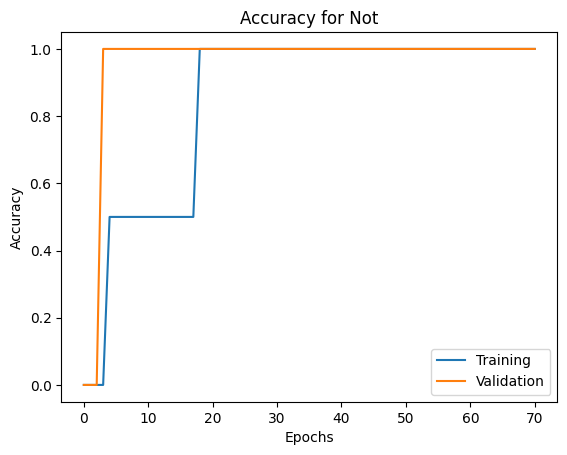

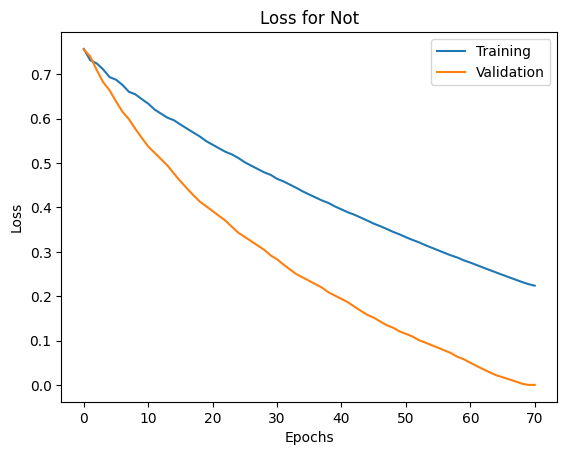

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 1.0000 - loss: 0.2221
loss: 0.22
compile_metrics: 100.00%


In [7]:
##################################
# 5 Plot Results
##################################

plotHistory(NOThistory, 'Not')

score = p1model.evaluate(xOne, yNot, batch_size=2, verbose=1)
print("%s: %.2f" % (p1model.metrics_names[0], score[0]))
print("%s: %.2f%%" % (p1model.metrics_names[1], score[1]*100))